# Análisis Exploratorio de Datos (EDA) - Customer Churn

**Objetivo:** Explorar la estructura del conjunto de datos, identificar problemas de calidad de datos, analizar la distribución de las variables y evaluar los factores de negocio asociados a la variable objetivo (`Churn`).

In [1]:
# 0. Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# 1. Carga de datos
DATA_PATH = Path("../data/raw/customer_churn_historical.csv")
df = pd.read_csv(DATA_PATH)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\raw\\customer_churn_historical.csv'

## 1. Estructura y Calidad de los Datos

Evaluación de las dimensiones del dataset, tipos de datos asignados y detección de valores nulos o registros duplicados.

In [ ]:
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas\n")

df.info()

print(f"\nFilas duplicadas: {df.duplicated().sum()}\n")

print("Valores faltantes por variable:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Dimensiones: 7043 filas, 21 columnas

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

In [ ]:
print("Verificación de Cardinalidad (Valores únicos por variable):")
print(df.nunique())

Verificación de Cardinalidad (Valores únicos por variable):
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      4436
TotalCharges        6967
Churn                  2
dtype: int64


> **Observación sobre `SeniorCitizen`**
>
> La variable `SeniorCitizen` se encuentra almacenada como `int64`, pero presenta únicamente los valores 0 y 1. Debido a que representa una condición categórica binaria y no una magnitud numérica, se inspeccionan sus valores antes de definir su tratamiento.

In [ ]:
print("Valores únicos detectados en la variable 'SeniorCitizen':")
print(df['SeniorCitizen'].unique())

Valores únicos detectados en la variable 'SeniorCitizen':
[0 1]


> **Conclusión**
>
> Los valores observados son únicamente 0 y 1. Por lo tanto, `SeniorCitizen` se tratará como una variable categórica binaria, transformando 0 en `No` y 1 en `Yes`.

In [ ]:
# --- ADECUACIÓN DE TIPO DE DATO: SeniorCitizen ---

# 1. Inspección del estado original
print("Estado original de 'SeniorCitizen':")
print(df['SeniorCitizen'].value_counts(dropna=False))
print("-" * 30)

# 2. Transformación de variable binaria codificada numéricamente a categórica nominal
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# 3. Verificación post-transformación
print("\nEstado transformado de 'SeniorCitizen':")
print(df['SeniorCitizen'].value_counts(dropna=False))

Estado original de 'SeniorCitizen':
SeniorCitizen
0    5845
1    1198
Name: count, dtype: int64
------------------------------

Estado transformado de 'SeniorCitizen':
SeniorCitizen
No     5845
Yes    1198
Name: count, dtype: int64


## 2. Análisis Univariado - Variables Categóricas

Verificación de cardinalidad por dimensión de negocio (demográfica, servicios y contractual).

In [ ]:
# Listados de dimensiones
dim_demografica = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
dim_servicios = ['PhoneService', 'MultipleLines', 'InternetService', 'TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']
dim_contractual = ['Contract', 'PaperlessBilling', 'PaymentMethod']

print("=== DIMENSIÓN DEMOGRÁFICA ===\n")
for col in dim_demografica:
    print(f"--- {col} ---")
    conteo = df[col].value_counts()
    porcentaje = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje.round(2)}))
    print("\n")

print("=== DIMENSIÓN DE SERVICIOS ===\n")
for col in dim_servicios:
    print(f"--- {col} ---")
    conteo = df[col].value_counts()
    porcentaje = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje.round(2)}))
    print("\n")

print("=== DIMENSIÓN CONTRACTUAL Y FINANCIERA ===\n")
for col in dim_contractual:
    print(f"--- {col} ---")
    conteo = df[col].value_counts()
    porcentaje = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje.round(2)}))
    print("\n")

=== DIMENSIÓN DEMOGRÁFICA ===

--- gender ---
        Cantidad  Porcentaje (%)
gender                          
Male        3560           50.55
Female      3483           49.45


--- SeniorCitizen ---
               Cantidad  Porcentaje (%)
SeniorCitizen                          
No                 5845           82.99
Yes                1198           17.01


--- Partner ---
         Cantidad  Porcentaje (%)
Partner                          
No           3623           51.44
Yes          3420           48.56


--- Dependents ---
            Cantidad  Porcentaje (%)
Dependents                          
No              4954           70.34
Yes             2089           29.66


=== DIMENSIÓN DE SERVICIOS ===

--- PhoneService ---
              Cantidad  Porcentaje (%)
PhoneService                          
Yes               6368           90.42
No                 675            9.58


--- MultipleLines ---
                  Cantidad  Porcentaje (%)
MultipleLines                        

## 3. Análisis de la Variable Objetivo (Churn)

Distribución de la clase a predecir y evaluación del desbalanceo.

Distribución de Churn (Objetivo):
No Churn: 5186 (73.63%)
Yes Churn: 1857 (26.37%)



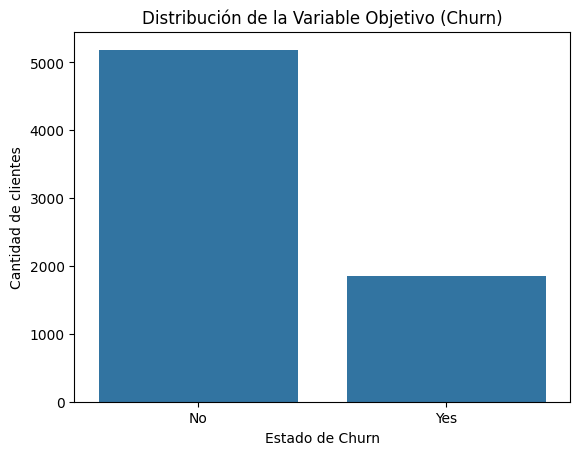

In [ ]:
# Conteo absoluto y porcentual
print("Distribución de Churn (Objetivo):")
conteo_churn = df['Churn'].value_counts()
porcentaje_churn = df['Churn'].value_counts(normalize=True) * 100

print(f"No Churn: {conteo_churn['No']} ({porcentaje_churn['No']:.2f}%)")
print(f"Yes Churn: {conteo_churn['Yes']} ({porcentaje_churn['Yes']:.2f}%)\n")

# Visualización
sns.countplot(data=df, x='Churn')
plt.title("Distribución de la Variable Objetivo (Churn)")
plt.xlabel("Estado de Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

"> **Interpretación**
>
> La distribución de la variable objetivo muestra que el **73,63 % de los clientes permanece en el servicio**, mientras que el **26,37 % realiza churn**. La clase `Churn = 1` es, por lo tanto, minoritaria, aunque cuenta con **1.857 observaciones**, por lo que existe un desbalance de clases moderado.
>
> Esta diferencia debe considerarse posteriormente al evaluar los modelos, ya que una Accuracy elevada puede resultar engañosa si el modelo favorece predominantemente a la clase mayoritaria.


## 4. Análisis Univariado - Variables Numéricas

Exploración de la distribución de las variables numéricas relacionadas con la antigüedad y la facturación de los clientes.

In [ ]:
print("Resumen estadístico de las variables numéricas:")
print(df.describe())

Resumen estadístico de las variables numéricas:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7017.000000
mean     35.168394       68.168503   2312.077586
std      18.901478       24.980659   1573.967858
min       0.000000       18.000000      0.000000
25%      20.000000       55.360000    986.630000
50%      35.000000       73.910000   2013.200000
75%      51.000000       88.000000   3452.850000
max      72.000000      114.410000   7761.340000


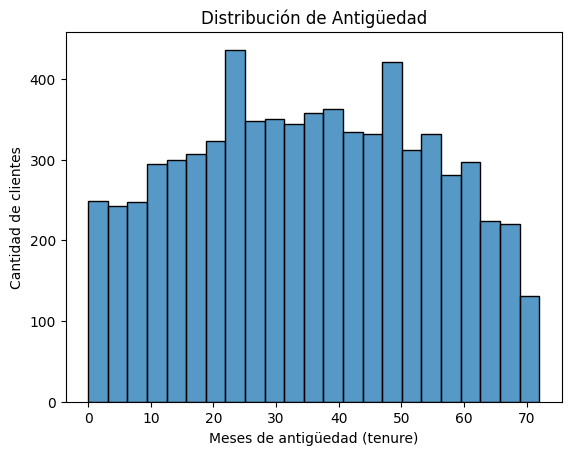

In [ ]:
# Distribución de antigüedad
sns.histplot(data=df, x='tenure')
plt.title("Distribución de Antigüedad")
plt.xlabel("Meses de antigüedad (tenure)")
plt.ylabel("Cantidad de clientes")
plt.show()


> **Interpretación de la antigüedad (`tenure`)**
>
> La antigüedad de los clientes se distribuye a lo largo de prácticamente todo el rango disponible, desde clientes recientemente incorporados hasta clientes con varios años de permanencia. No se observa una concentración exclusiva en un único nivel de antigüedad, lo que indica que la base contiene clientes en distintas etapas de su relación con la empresa.
>
> Esta variable resulta especialmente relevante para el análisis de churn, ya que posteriormente permitirá evaluar si la permanencia del cliente se relaciona con una mayor o menor probabilidad de abandono.

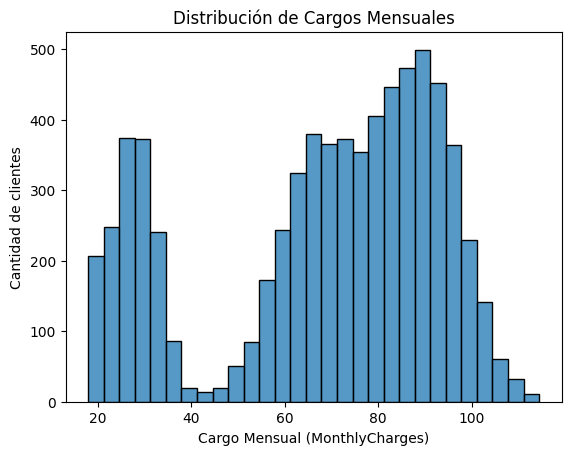

In [ ]:
# Distribución de cargos mensuales
sns.histplot(data=df, x='MonthlyCharges')
plt.title("Distribución de Cargos Mensuales")
plt.xlabel("Cargo Mensual (MonthlyCharges)")
plt.ylabel("Cantidad de clientes")
plt.show()

> **Interpretación de los cargos mensuales (`MonthlyCharges`)**
>
> Los cargos mensuales no presentan una distribución uniforme. Se observa un grupo de clientes con cargos relativamente bajos y una mayor concentración de casos en niveles medios y altos de facturación.
>
> Esta variabilidad puede estar vinculada con las diferentes combinaciones de servicios contratados. Por este motivo, `MonthlyCharges` resulta una variable de interés para analizar posteriormente si determinados niveles de facturación se encuentran asociados con una mayor tasa de abandono.

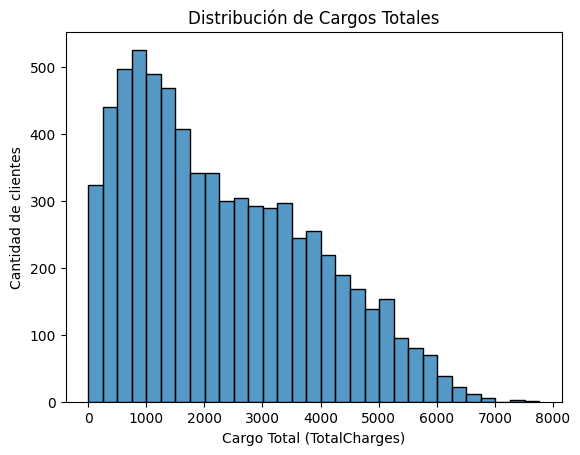

In [ ]:
# Distribución de cargos totales (omitiendo nulos temporalmente)
sns.histplot(data=df.dropna(subset=['TotalCharges']), x='TotalCharges')
plt.title("Distribución de Cargos Totales")
plt.xlabel("Cargo Total (TotalCharges)")
plt.ylabel("Cantidad de clientes")
plt.show()

> **Interpretación de los cargos totales (`TotalCharges`)**
>
> La distribución de `TotalCharges` presenta una asimetría hacia la derecha: la mayor cantidad de clientes se concentra en niveles bajos y medios de facturación acumulada, mientras que una cantidad progresivamente menor alcanza valores elevados.
>
> Este comportamiento es coherente con una variable acumulativa, ya que el cargo total depende tanto del nivel de facturación mensual como del tiempo de permanencia del cliente. Por esta razón, su interpretación debe realizarse conjuntamente con variables como `tenure` y `MonthlyCharges`.

> **Profundización sobre los valores faltantes**
>
> Durante la revisión inicial de calidad de los datos se identificaron 26 valores faltantes en `TotalCharges`. Como esta variable representa cargos acumulados, se busca contextualizar estos registros explorando su relación con la antigüedad del cliente (`tenure`).

In [ ]:
# Verificación de los registros con TotalCharges faltante
print("Tenure de los clientes con TotalCharges faltante:")
print(df.loc[df['TotalCharges'].isna(), 'tenure'].value_counts())

Tenure de los clientes con TotalCharges faltante:
tenure
0    26
Name: count, dtype: int64


> **Resultado**
>
> Los 26 registros con `TotalCharges` faltante corresponden a clientes con `tenure = 0`. El patrón es consistente con clientes recientemente incorporados, para quienes todavía no se registran cargos acumulados.
>
> Los valores faltantes no se eliminan del conjunto de datos. El tratamiento definitivo se realizará posteriormente dentro del pipeline de preprocesamiento, mediante imputación ajustada sobre el conjunto de entrenamiento para evitar fuga de información.


## 5. Análisis Bivariado - Factores Asociados al Churn
Cruce de las principales dimensiones de negocio con la variable objetivo para la identificación de perfiles con alta tasa de abandono.

> **Criterio de análisis**
>
> Para cada variable categórica se calcula la proporción de clientes que realiza `Churn` dentro de cada categoría. Este enfoque permite comparar las categorías según su tasa de abandono, independientemente de la cantidad total de clientes que pertenezca a cada una.

>**Nota sobre la selección de variables para el análisis bivariado**
>
> En esta sección se profundiza el análisis de la relación entre determinadas variables categóricas y el abandono del cliente. Se seleccionan variables consideradas relevantes para su interpretación desde una perspectiva de negocio, agrupadas en tres dimensiones:
>
> **Estructura contractual y financiera:** tipo de contrato, medio de pago y modalidad de facturación.
>
> **Demografía:** condición de adulto mayor, presencia de pareja y dependientes.
>
> **Servicios y vinculación con el cliente:** servicio de Internet, múltiples líneas, seguridad online, soporte técnico, backup y protección de dispositivos.
>
> Las variables relacionadas con servicios de entretenimiento, como `StreamingTV` y `StreamingMovies`, no se incluyen en esta inspección detallada para mantener el análisis focalizado. Esto **no implica que sean irrelevantes**: todas las variables disponibles se incorporarán posteriormente al modelado predictivo, excluyendo únicamente `customerID` y `Churn`.


In [ ]:
variables_riesgo = [
    # Financieras / Contrato
    'Contract', 'PaymentMethod', 'PaperlessBilling',
    # Servicios
    'InternetService', 'MultipleLines', 'TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    # Demográficas
    'SeniorCitizen', 'Partner', 'Dependents'
]


In [ ]:
print("=== TASA DE ABANDONO (%) POR CATEGORÍA ===\n")
for col in variables_riesgo:
    print(f"--- {col} ---")
    cruce = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(cruce.round(2))
    print("\n")

=== TASA DE ABANDONO (%) POR CATEGORÍA ===

--- Contract ---
Churn              No    Yes
Contract                    
Month-to-month  61.27  38.73
One year        85.03  14.97
Two year        91.03   8.97


--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  76.98  23.02
Credit card (automatic)    75.43  24.57
Electronic check           68.94  31.06
Mailed check               75.61  24.39


--- PaperlessBilling ---
Churn                No    Yes
PaperlessBilling              
No                75.31  24.69
Yes               72.45  27.55


--- InternetService ---
Churn               No    Yes
InternetService              
DSL              80.03  19.97
Fiber optic      59.75  40.25
No               92.38   7.62


--- MultipleLines ---
Churn                No    Yes
MultipleLines                 
No                74.10  25.90
No phone service  75.85  24.15
Yes               72.56  27.44


--- TechSupport ---
Ch

> **Interpretación de las variables categóricas según Churn**
>
> El cruce de las variables categóricas con `Churn` permite identificar diferencias descriptivas en las tasas de abandono entre categorías.
>
> En la dimensión contractual, los clientes con contrato **Month-to-month** presentan la mayor tasa de churn (**38,73 %**), mientras que los contratos de dos años presentan una tasa considerablemente menor (**8,97 %**). En cuanto al medio de pago, **Electronic check** presenta la mayor tasa de abandono (**31,06 %**) entre las categorías de `PaymentMethod`.
>
> Dentro de los servicios, **Fiber optic** presenta la mayor tasa de churn de `InternetService` (**40,25 %**). También se observan tasas superiores en las categorías `No` de `TechSupport` (**34,18 %**) y `OnlineSecurity` (**35,06 %**). Sin embargo, este comportamiento no es uniforme: en `OnlineBackup` y `DeviceProtection`, la tasa de churn es ligeramente mayor entre quienes tienen el servicio (`Yes`) que entre quienes no lo tienen (`No`).
>
> En las variables demográficas, `SeniorCitizen = Yes` presenta una tasa de churn del **29,88 %**, frente al **25,65 %** de `SeniorCitizen = No`. Asimismo, los clientes sin pareja (`Partner = No`) presentan **27,85 %** frente a **24,80 %** con pareja, y quienes no tienen dependientes (`Dependents = No`) presentan **27,25 %** frente a **24,27 %** con dependientes.
>
> Estas diferencias son descriptivas y no permiten establecer relaciones causales.


In [ ]:
print("\n=== ANTIGÜEDAD Y CARGOS SEGÚN CHURN ===")
print("\nPromedios de Antigüedad y Facturación según Churn:")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2))


=== ANTIGÜEDAD Y CARGOS SEGÚN CHURN ===

Promedios de Antigüedad y Facturación según Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.28           63.94       2324.70
Yes     29.28           79.98       2276.81


> **Interpretación de las variables numéricas según Churn**
>
> Los clientes que realizan churn presentan una antigüedad promedio menor (**29,28 meses**) que quienes permanecen (**37,28 meses**), mientras que su cargo mensual promedio es superior (**79,98 frente a 63,94**).
>
> En cambio, el `TotalCharges` promedio resulta relativamente similar entre ambos grupos (**2276,81** en clientes con churn frente a **2324,70** en clientes sin churn). Esto es compatible con la combinación de una mayor facturación mensual y una menor antigüedad promedio entre quienes abandonan.
>
> Estos promedios son asociaciones descriptivas; no permiten concluir por sí solos que un mayor cargo mensual o una menor antigüedad causen el churn.


El análisis exploratorio permite identificar características asociadas a diferentes tasas de abandono y establece una base para el posterior modelado predictivo. Los principales hallazgos son los siguientes:

### Calidad de datos y distribución general

* El dataset consta de **7043 registros y 21 variables**.
* Se detectaron **26 valores faltantes**, todos localizados en `TotalCharges`.
* La tasa base de abandono es del **26,37 % (1857 clientes)**, frente al **73,63 % (5186 clientes)** que permanecen en el servicio. La clase positiva es minoritaria, por lo que existe un desbalance moderado.

### Factores asociados al abandono

**Dimensión contractual y financiera**

* Los contratos **Month-to-month** presentan la mayor tasa de abandono entre las categorías de `Contract`, con **38,73 %**, mientras que los contratos de dos años presentan **8,97 %**.
* **Electronic check** presenta la mayor tasa de abandono entre las categorías de `PaymentMethod`, con **31,06 %**.
* Estos resultados son asociaciones descriptivas y no implican causalidad.

**Antigüedad y cargos**

* Los clientes que abandonan presentan, en promedio, **menor antigüedad y mayores cargos mensuales** que los clientes que permanecen.
* El cargo mensual promedio es de **79,98** para quienes realizan churn, frente a **63,94** para quienes permanecen.
* La antigüedad media es de **29,28 meses** entre quienes abandonan, frente a **37,28 meses** entre quienes permanecen.
* Aunque el cargo mensual promedio es mayor entre quienes realizan churn, el `TotalCharges` promedio es similar (**2276,81** frente a **2324,70**), en línea con la combinación de menor antigüedad y mayor cargo mensual.

**Servicios y perfil del cliente**

* `Fiber optic` presenta la mayor tasa de churn dentro de `InternetService`, con **40,25 %**, frente a **19,97 %** en DSL y **7,62 %** entre quienes no poseen servicio de Internet.
* En `TechSupport` y `OnlineSecurity`, la categoría `No` presenta tasas de churn superiores (**34,18 %** y **35,06 %**, respectivamente). En cambio, en `OnlineBackup` y `DeviceProtection`, las categorías `Yes` presentan tasas ligeramente superiores a las categorías `No`.
* Entre las variables demográficas, `SeniorCitizen = Yes` presenta una tasa superior (**29,88 %**) a `No` (**25,65 %**). También se observan diferencias moderadas según `Partner` y `Dependents`.
* En conjunto, estos resultados muestran asociaciones descriptivas, no relaciones causales.

### Consideración desde la perspectiva de BI

La tasa de churn permite identificar qué categorías presentan una mayor proporción de abandono, pero no refleja por sí sola el volumen de clientes afectados.

Por este motivo, una profundización posterior debería considerar conjuntamente **tasa de abandono y cantidad de clientes** de cada segmento. Un segmento pequeño puede presentar una tasa elevada y representar pocos casos, mientras que otro con una tasa menor puede concentrar un volumen mayor de clientes.

En esta etapa no se cuantifica el impacto económico, ya que los datos disponibles no permiten estimar de forma directa el valor recuperable mediante acciones de retención ni su costo o efectividad.

### Preparación para el modelado

Los 26 valores nulos identificados en `TotalCharges` requieren un tratamiento dentro del pipeline de preprocesamiento. Para mantener la reproducibilidad y evitar fugas de información, la imputación se realizará posteriormente como parte del pipeline de `scikit-learn`.

Asimismo, dado que los clientes que realizan churn presentan un cargo mensual promedio superior, un falso negativo —un cliente que efectivamente abandona pero que el modelo no identifica como positivo— podría representar una oportunidad de retención perdida, especialmente cuando se trata de clientes con cargos elevados. Esto constituye una **hipótesis de negocio**, no una cuantificación del impacto económico, ya que los datos disponibles no permiten estimar cuánto ingreso podría recuperarse mediante una intervención.

El criterio de evaluación y las métricas seleccionadas se desarrollarán específicamente en la sección de modelado.


## 6. Partición Reproducible de Datos

Separación de las variables predictoras (`X`) y la variable objetivo (`y`). Se reserva un conjunto de prueba (`test`) utilizando estratificación para mantener una proporción de clases similar a la del conjunto original y una semilla aleatoria para garantizar la reproducibilidad.


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separar features y target
# Eliminamos 'customerID' ya que es un identificador y no un predictor
X = df.drop(columns=['Churn', 'customerID'])

# Binarizamos el target para definir explícitamente la clase positiva:
# 0 = No Churn, 1 = Churn
y = df['Churn'].map({'No': 0, 'Yes': 1})

# 2. Partición Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Verificación de las dimensiones y proporción del target
print("=== DIMENSIONES DE LA PARTICIÓN ===")
print(f"Entrenamiento (Train): {X_train.shape[0]} filas")
print(f"Evaluación (Test): {X_test.shape[0]} filas\n")

print("=== DISTRIBUCIÓN DEL TARGET (Estratificación) ===")
print(f"Proporción de Churn en Train: {y_train.mean():.2%}")
print(f"Proporción de Churn en Test: {y_test.mean():.2%}")

=== DIMENSIONES DE LA PARTICIÓN ===
Entrenamiento (Train): 5634 filas
Evaluación (Test): 1409 filas

=== DISTRIBUCIÓN DEL TARGET (Estratificación) ===
Proporción de Churn en Train: 26.36%
Proporción de Churn en Test: 26.40%


> **Interpretación de la partición**
>
> La división reserva **80 % de las observaciones para entrenamiento (5634 clientes)** y **20 % para evaluación (1409 clientes)**. La utilización de `stratify=y` mantiene proporciones de clase muy similares: **26,36 % de churn en Train y 26,40 % en Test**, frente a **26,37 % en el dataset completo**.
>
> `random_state=42` hace reproducible la partición: al ejecutar nuevamente este código sobre los mismos datos y con la misma configuración, se obtiene la misma separación.
>
> El conjunto de prueba `test` queda fuera del ajuste de los modelos y se utiliza para estimar su desempeño sobre observaciones no utilizadas durante el entrenamiento.


## 7. Pipeline de Preprocesamiento
Creación de flujos de transformación independientes para variables numéricas (imputación de nulos y escalado) y variables categóricas (codificación One-Hot), consolidados a través de un `ColumnTransformer`.

> División del flujo de preprocesamiento en dos ramas mediante un `ColumnTransformer`:
>
> 1. **Rama numérica:** toma `tenure`, `MonthlyCharges` y `TotalCharges`; aplica `SimpleImputer(strategy='median')` para completar los valores faltantes y luego `StandardScaler` para estandarizar las variables. El escalado es especialmente relevante para la Regresión Logística.
>
> 2. **Rama categórica:** toma las variables categóricas y las transforma mediante `OneHotEncoder(handle_unknown='ignore')`. No se aplica imputación categórica porque no se detectaron valores faltantes en estas variables.
>
> Al estar el preprocesamiento dentro de un `Pipeline`, los parámetros de imputación y escalado se ajustan únicamente con los datos de entrenamiento cuando se hace `fit`, evitando fuga de información hacia el conjunto de prueba.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identificación de tipos de variables
variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
variables_categoricas = X_train.select_dtypes(include=['str']).columns.tolist()

# Pipeline para variables numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Ensamblado del preprocesador unificado
preprocesador = ColumnTransformer([
    ('num', num_pipeline, variables_numericas),
    ('cat', cat_pipeline, variables_categoricas)
])

> Lógica del preprocesamiento:
>
> Las variables numéricas se imputan y escalan, mientras que las variables categóricas se transforman mediante One-Hot Encoding. ColumnTransformer permite aplicar cada tratamiento únicamente a las columnas correspondientes y combinar posteriormente ambas ramas en una única representación numérica que pueda utilizar el modelo.

## 8. Criterio de Evaluación Predictiva

El problema de Customer Churn presenta un desbalance moderado: aproximadamente el **26 %** de los clientes pertenecen a la clase positiva (`Churn = 1`). Por este motivo, la Accuracy no se utilizará como única métrica de evaluación, ya que un modelo puede obtener una exactitud elevada favoreciendo la clase mayoritaria.

Se evaluarán los modelos mediante:

* **Precision:** proporción de clientes predichos como churn que efectivamente abandonan.
* **Recall:** proporción de clientes que efectivamente abandonan y son correctamente identificados.
* **F1-score:** media armónica entre Precision y Recall, útil para valorar ambas métricas conjuntamente.
* **ROC-AUC:** capacidad discriminativa del modelo para separar clientes con y sin churn a través de distintos umbrales.
* **Matriz de confusión:** permite analizar directamente verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
* **Accuracy:** se conservará como métrica descriptiva complementaria, pero no se utilizará de manera aislada para seleccionar el modelo.

### Criterio de negocio

Se priorizará especialmente el **Recall de la clase positiva**, porque un falso negativo representa un cliente que efectivamente abandona el servicio y no es identificado como tal.

Sin embargo, el Recall no se analizará de forma aislada. Un modelo que clasifique excesivamente clientes como churn puede alcanzar un Recall elevado a costa de una Precision baja y generar intervenciones comerciales innecesarias.

Por lo tanto, la selección del modelo candidato considerará principalmente el Recall, acompañado por Precision, F1-score y ROC-AUC.


## 9. Modelado y Evaluación Predictiva

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Lista para consolidar las métricas de cada modelo al final
resultados = []

def graficar_matriz(modelo, X_test, y_test, titulo):
    disp = ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test, 
        display_labels=['No Churn', 'Churn'],
    )
    disp.ax_.set_title(titulo)
    plt.show()

### 9.1 Baseline: Dummy Classifier

El `DummyClassifier` se utiliza como modelo de referencia o **baseline**. No aprende relaciones entre las variables predictoras y la variable objetivo, sino que establece un nivel de desempeño contra el cual comparar los modelos predictivos.

Se utiliza la estrategia `prior`. En este caso, al existir una clase mayoritaria (`No Churn`), el modelo predice esa clase para todas las observaciones, mientras que sus probabilidades reflejan la distribución de clases del conjunto de entrenamiento.

Este baseline permite verificar si los modelos posteriores aportan capacidad predictiva más allá de una estrategia que no utiliza las características de los clientes.


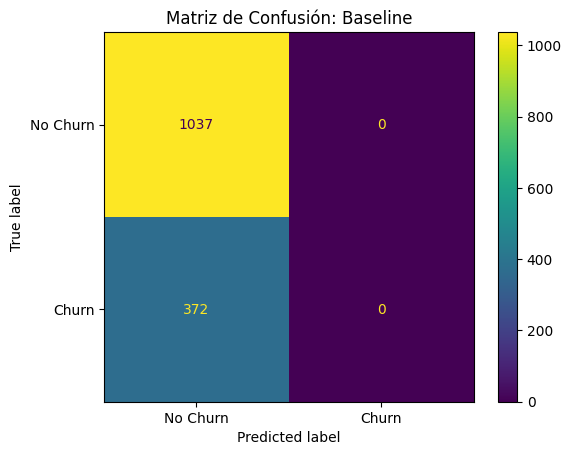

In [ ]:
# Entrenamiento
pipeline_dummy = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', DummyClassifier(strategy='prior'))
])
pipeline_dummy.fit(X_train, y_train)

# Predicción
y_pred_dummy = pipeline_dummy.predict(X_test)
y_proba_dummy = pipeline_dummy.predict_proba(X_test)[:, 1]

# Evaluación Visual y Métricas
graficar_matriz(pipeline_dummy, X_test, y_test, 'Matriz de Confusión: Baseline')

resultados.append({
    'Modelo': 'Baseline (Dummy)',
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dummy),
    'F1-Score': f1_score(y_test, y_pred_dummy),
    'ROC-AUC': roc_auc_score(y_test, y_proba_dummy)
})

### Interpretación

El `Dummy Classifier` clasifica los 1.409 clientes del conjunto de prueba como `No Churn`. Como consecuencia, identifica correctamente a los clientes que efectivamente no abandonan (`TN`), pero no identifica ninguno de los clientes que efectivamente presentan `Churn`, por lo que no se observan verdaderos positivos (`TP = 0`) y todos los casos de churn quedan como falsos negativos (`FN`).

Esta matriz permite visualizar el comportamiento esperado de un modelo baseline que no utiliza relaciones entre las características de los clientes y el abandono.


### 9.2 Modelo Lineal: Regresión Logística

La Regresión Logística se utiliza como modelo lineal de clasificación para estimar la probabilidad de que un cliente pertenezca a la clase positiva (`Churn = 1`).

Se incorpora `class_weight='balanced'` para asignar mayor peso a la clase minoritaria durante el entrenamiento y reducir el efecto del desbalance sobre el ajuste.

Este modelo establece una referencia predictiva basada en relaciones lineales entre las variables preprocesadas y la probabilidad de churn.


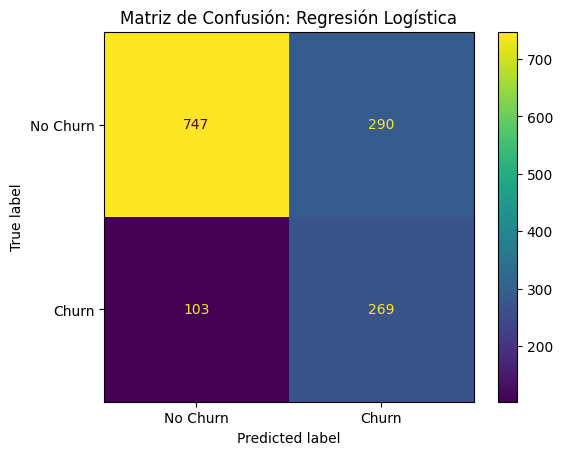

In [ ]:
# Entrenamiento
pipeline_lr = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])
pipeline_lr.fit(X_train, y_train)

# Predicción
y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# Evaluación Visual y Métricas
graficar_matriz(pipeline_lr, X_test, y_test, 'Matriz de Confusión: Regresión Logística')

resultados.append({
    'Modelo': 'Regresión Logística (Balanced)',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
})

### Interpretación

La matriz de confusión muestra que la Regresión Logística clasifica correctamente 747 clientes que no presentan `Churn` (`TN`) y 269 clientes que efectivamente abandonan el servicio (`TP`). Al mismo tiempo, se observan 290 falsos positivos (`FP`), correspondientes a clientes que fueron clasificados como `Churn` pero finalmente no abandonaron, y 103 falsos negativos (`FN`), correspondientes a clientes que abandonaron pero no fueron identificados por el modelo.

Desde el punto de vista del problema de negocio, los falsos negativos representan casos especialmente relevantes, ya que corresponden a clientes que efectivamente abandonan el servicio y que el modelo no logra identificar.


### 9.3 Modelo Basado en Árboles: Random Forest

El **Random Forest** combina múltiples árboles de decisión entrenados con muestras y subconjuntos aleatorios de variables. El ensamble busca reducir la variabilidad de un árbol individual y obtener predicciones más estables.

En esta primera configuración se utiliza `class_weight='balanced'` para considerar el desbalance entre las clases durante el entrenamiento.

Además, se establece `max_depth=10` para limitar la complejidad de cada árbol. Esta es una **decisión de regularización**, orientada a reducir el riesgo de sobreajuste; el notebook no realiza una comparación específica de desempeño train/test que permita demostrar cuánto se reduce ese riesgo.


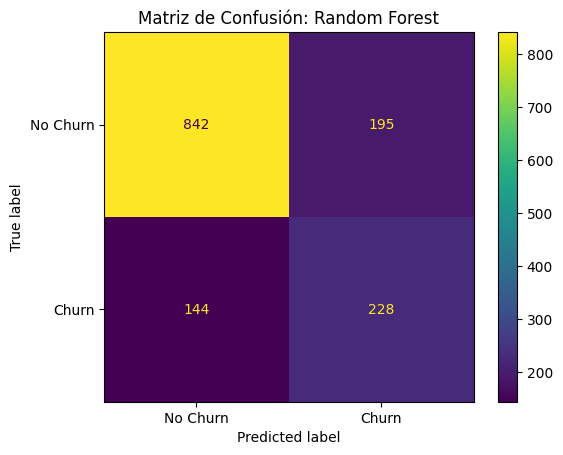

In [ ]:
# Entrenamiento
pipeline_rf = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(
        random_state=42, 
        n_estimators=100, 
        class_weight='balanced',
        max_depth=10 
    ))
])
pipeline_rf.fit(X_train, y_train)

# Predicción
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Evaluación Visual y Métricas
graficar_matriz(pipeline_rf, X_test, y_test, 'Matriz de Confusión: Random Forest')

resultados.append({
    'Modelo': 'Random Forest (Balanced)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf)
})

### Interpretación

La matriz de confusión muestra que el Random Forest clasifica correctamente 842 clientes que no presentan `Churn` (`TN`) y 228 clientes que efectivamente abandonan el servicio (`TP`). Por otro lado, se observan 195 falsos positivos (`FP`), correspondientes a clientes que fueron clasificados como `Churn` pero finalmente no abandonaron, y 144 falsos negativos (`FN`), correspondientes a clientes que abandonaron pero no fueron identificados por el modelo.

Desde el punto de vista del problema de negocio, los 144 falsos negativos representan clientes que efectivamente abandonan el servicio y que el modelo no logra detectar.


## 10. Comparación de Modelos
### 10.1 Tabla Comparativa de Métricas

In [ ]:
df_resultados = pd.DataFrame(resultados).set_index("Modelo")

print("=== RESUMEN DE MÉTRICAS ===")
df_resultados.round(2)

=== RESUMEN DE MÉTRICAS ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Baseline (Dummy),0.74,0.00,0.00,0.00,0.50
Regresión Logística (Balanced),0.72,0.48,0.72,0.58,0.81
Random Forest (Balanced),0.76,0.54,0.61,0.57,0.80


### 10.2 Comparación de Resultados y Selección del Modelo Candidato

Los resultados muestran diferencias claras según la métrica considerada. El `Dummy Classifier` obtiene una `Accuracy` de **0,74**, pero no identifica ningún caso de `Churn`: `Precision`, `Recall` y `F1-score` son **0**, y `ROC-AUC = 0,50`. Esto confirma su utilidad como nivel de referencia, no como modelo predictivo competitivo.

La **Regresión Logística** obtiene `Recall = 0,72`, `Precision = 0,48`, `F1-score = 0,58` y `ROC-AUC = 0,81`, con `Accuracy = 0,72`. Es el modelo que logra detectar una mayor proporción de los churn reales entre los modelos evaluados.

El **Random Forest** obtiene `Accuracy = 0,76`, `Precision = 0,54`, `Recall = 0,61`, `F1-score = 0,57` y `ROC-AUC = 0,80`. Por lo tanto, supera a la Regresión Logística en Accuracy y Precision, pero queda por debajo en Recall, F1-score y ROC-AUC.

No existe un modelo que domine en todas las métricas. La Regresión Logística favorece la detección de una mayor proporción de clientes que efectivamente realizan churn, mientras que Random Forest presenta una menor cantidad de falsos positivos y obtiene una mayor exactitud global.

Considerando que para este caso de negocio se definió el `Recall` de la clase positiva como métrica prioritaria, acompañado por `Precision`, `F1-score` y `ROC-AUC` como métricas complementarias, se selecciona la **Regresión Logística como modelo candidato de esta primera iteración**.

Esta selección no implica que sea definitivamente el mejor modelo posible. Las métricas corresponden a **una única partición Train/Test** y no se realizó validación cruzada ni ajuste del umbral de decisión. Por lo tanto, la conclusión debe interpretarse como una selección inicial condicionada al criterio de negocio definido.

El `Random Forest` queda como una alternativa competitiva, especialmente si en iteraciones posteriores se busca mejorar el equilibrio entre detección de churn y cantidad de falsas alarmas.
